In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
dataframe=pd.read_csv('/content/books.csv', on_bad_lines='skip')
dataframe=dataframe.drop(['Unnamed: 12'], axis=1)

dataframe.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,34889,Brown's Star Atlas: Showing All The Bright Sta...,Brown,Son & Ferguson,0,851742718,9.78E+12,eng,49,0,0,05-01-1977
1,22128,Patriots (The Coming Collapse),James Wesley,Rawles,3.63,156384155X,9.78E+12,eng,342,38,4,1/15/1999
2,16914,The Tolkien Fan's Medieval Reader,David E. Smith (Turgon of TheOneRing.net,one of the founding members of this Tolkien w...,3.58,1593600119,9.78E+12,eng,400,26,4,04-06-2004
3,12224,Streetcar Suburbs: The Process of Growth in Bo...,Sam Bass Warner,Jr./Sam B. Warner,3.58,674842111,9.78E+12,en-US,236,61,6,4/20/2004
4,2034,Comoediae 1: Acharenses/Equites/Nubes/Vespae/P...,Aristophanes/F.W. Hall/W.M. Geldart,5,198145047,9.78E+12,grc,364,0,0,2/22/1922,Oxford University Press USA


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,34889,Brown's Star Atlas: Showing All The Bright Sta...,Brown,Son & Ferguson,0,851742718,9.78E+12,eng,49,0,0,05-01-1977
1,22128,Patriots (The Coming Collapse),James Wesley,Rawles,3.63,156384155X,9.78E+12,eng,342,38,4,1/15/1999
2,16914,The Tolkien Fan's Medieval Reader,David E. Smith (Turgon of TheOneRing.net,one of the founding members of this Tolkien w...,3.58,1593600119,9.78E+12,eng,400,26,4,04-06-2004
3,12224,Streetcar Suburbs: The Process of Growth in Bo...,Sam Bass Warner,Jr./Sam B. Warner,3.58,674842111,9.78E+12,en-US,236,61,6,4/20/2004
4,2034,Comoediae 1: Acharenses/Equites/Nubes/Vespae/P...,Aristophanes/F.W. Hall/W.M. Geldart,5,198145047,9.78E+12,grc,364,0,0,2/22/1922,Oxford University Press USA


In [9]:
from sklearn.ensemble import RandomForestClassifier

In [10]:
from sklearn.model_selection import train_test_split#importing the Random Forest classifier
from sklearn.preprocessing import StandardScaler#importing the Standard Scalar
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix,classification_report#importing the confusion matrix and classification report

In [11]:
top_ten_ratings=dataframe[dataframe['ratings_count']>1000000]#getting the rows with most ratings
top_ten_ratings=top_ten_ratings.sort_values(by='ratings_count', ascending=False).head(10)#priting the sorted data

dataframe=dataframe.sort_values('average_rating').reset_index(drop=True)#sorting the dataframe according to average rating
dataframe=dataframe.iloc[4:]
dataframe.average_rating=dataframe.average_rating.astype(float)#changing the type to float
dataframe=dataframe.iloc[4:]
dataframe.num_pages=dataframe.num_pages.astype(float)#changing the type to float

In [12]:
dataframe2=dataframe.copy()
dataframe2.loc[(dataframe2['average_rating']>=0)&(dataframe2['average_rating']<=1),'rating between']="between 0 and 1"#getting the rows with average rating between 0 and 1
dataframe2.loc[(dataframe2['average_rating']>1)&(dataframe2['average_rating']<=2),'rating between']="between 1 and 2"#getting the rows with average rating between 1 and 2
dataframe2.loc[(dataframe2['average_rating']>2)&(dataframe2['average_rating']<=3),'rating between']="between 2 and 3"#getting the rows with average rating between 2 and 3
dataframe2.loc[(dataframe2['average_rating']>3)&(dataframe2['average_rating']<=4),'rating between']="between 3 and 4"#getting the rows with average rating between 3 and 4
dataframe2.loc[(dataframe2['average_rating']>4)&(dataframe2['average_rating']<=5),'rating between']="between 4 and 5"#getting the rows with average rating between 4 and 5
dataframe2.sort_values('average_rating')#sorting the dataframe

dataframe_rating=pd.get_dummies(dataframe2['rating between'])
dataframe_language=pd.get_dummies(dataframe2['language_code'])
feature_dataframe=pd.concat([dataframe_rating, dataframe_language, dataframe2['average_rating'], dataframe2['ratings_count']], axis=1)

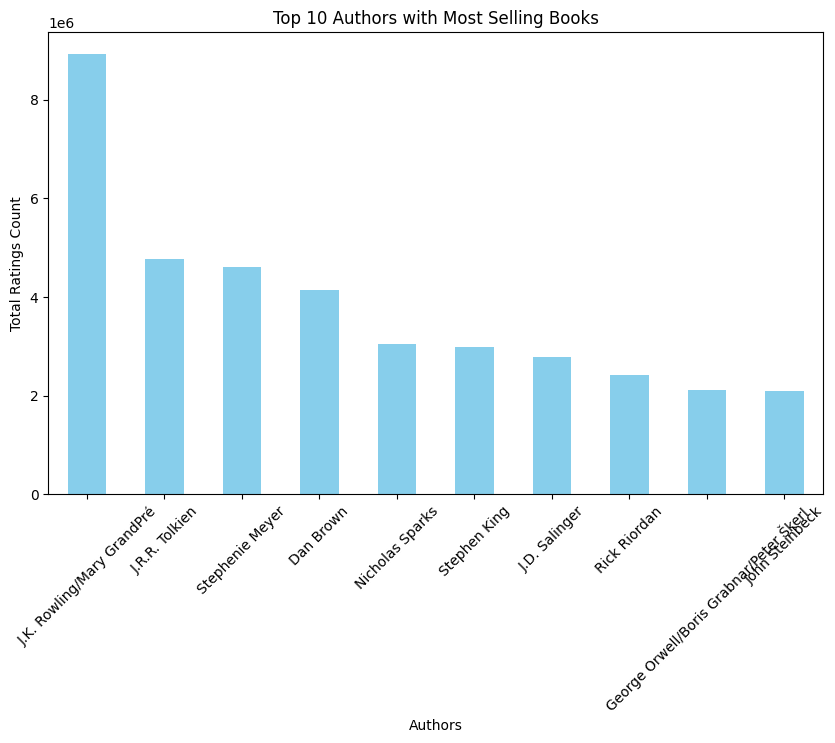

In [14]:
top_authors = dataframe.groupby('authors')['ratings_count'].sum().nlargest(10)

# Plot bar chart
plt.figure(figsize=(10,6))
top_authors.plot(kind='bar', color='skyblue')
plt.title('Top 10 Authors with Most Selling Books')
plt.xlabel('Authors')
plt.ylabel('Total Ratings Count')
plt.xticks(rotation=45)
plt.show()

In [15]:
from sklearn.preprocessing import MinMaxScaler
from sklearn import neighbors

# Select numerical features for recommendation
feature = dataframe2[['average_rating', 'ratings_count', 'text_reviews_count', 'num_pages']]

# Create MinMaxScaler
minmax = MinMaxScaler()

# Scale the features
feature = minmax.fit_transform(feature)

# Create the KNN model
model = neighbors.NearestNeighbors(
    n_neighbors=8,
    algorithm='ball_tree'
)

# Fit the model
model.fit(feature)

# Find nearest books
dist, book_id = model.kneighbors(feature)


def recommend_book(name):
    book_list = []

    # Find the index of the requested book
    book_index = dataframe2[dataframe2['title'] == name].index

    # Check if the book exists
    if len(book_index) == 0:
        return ["Book not found"]

    book_index = book_index[0]

    # Get recommended books
    for books in book_id[book_index]:
        book_list.append(dataframe2.loc[books, 'title'])

    return book_list


In [ ]:
def recommend_book(name):
    book_list = []

    book_index = dataframe2[dataframe2['title'].str.lower() == name.lower()].index

    if len(book_index) == 0:
        return ["Book not found. Please check the book title."]

    book_index = book_index[0]

    for books in book_id[book_index]:
        book_list.append(dataframe2.loc[books, 'title'])

    return book_list


# Take input from user
name = input("Enter a book name: ")

result = recommend_book(name)

print("\nRecommended books:")
for book in result:
    print(book)
